In [ ]:
from hourly_shift_model_v3 import (
    build_actual_baseline_reference,
    build_issue_catalog,
    load_predictions,
    load_system_load,
    run_scenario,
    summarize_actual_baseline,
)

preds = load_predictions()
system_load = load_system_load()
issue_times = build_issue_catalog(preds)["issue_time"].tail(365)

baseline_ref = build_actual_baseline_reference(issue_times, preds, system_load)
baseline_summary = summarize_actual_baseline(baseline_ref)

full_period_baseline_p95 = system_load["system_load_mwh"].quantile(0.95)

summary, profiles, shifts = run_scenario(
    scenario_name="V3 Stateful Scenario",
    scenario_shares={"wet_loads": 0.1, "thermal": 0.2, "ev": 0.1},
    issue_times=issue_times,
    preds=preds,
    system_load=system_load,
    baseline_reference_p95_mwh=full_period_baseline_p95,
    return_profiles=True,
)


In [2]:
baseline_summary["baseline_system_load_p95_mwh"],

(3772.78028625,)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

profiles = profiles.copy()
shifts = shifts.copy()

profiles["target_time"] = pd.to_datetime(profiles["target_time"])
if not shifts.empty:
    shifts["origin_time"] = pd.to_datetime(shifts["origin_time"])
    shifts["target_time"] = pd.to_datetime(shifts["target_time"])

profiles["hour"] = profiles["target_time"].dt.hour
profiles["dayofweek"] = profiles["target_time"].dt.dayofweek
profiles["day_name"] = profiles["target_time"].dt.day_name()
profiles["is_weekend"] = profiles["dayofweek"] >= 5
profiles["day_type"] = np.where(profiles["is_weekend"], "Weekend", "Weekday")

baseline_p95 = full_period_baseline_p95

profiles["baseline_peak_hour"] = profiles["system_load_mwh"] >= baseline_p95
profiles["shifted_peak_hour"] = profiles["shifted_system_load_mwh"] >= baseline_p95

profiles["system_load_delta_mwh"] = (
    profiles["shifted_system_load_mwh"] - profiles["system_load_mwh"]
)
profiles["peak_headroom_delta_mwh"] = np.maximum(
    profiles["shifted_system_load_mwh"] - baseline_p95, 0
) - np.maximum(
    profiles["system_load_mwh"] - baseline_p95, 0
)


In [4]:
issue_times = pd.to_datetime(issue_times).sort_values()

issue_times.min(), issue_times.max(), len(issue_times), issue_times.diff().value_counts().head()


(Timestamp('2025-10-02 12:00:00'),
 Timestamp('2026-04-07 12:00:00'),
 365,
 issue_time
 0 days 12:00:00    363
 5 days 12:00:00      1
 Name: count, dtype: int64)

In [5]:
period_summary = pd.Series({
    "profile_start": profiles["target_time"].min(),
    "profile_end": profiles["target_time"].max(),
    "profile_hours": len(profiles),
    "profile_days": len(profiles) / 24,
    "issue_start": issue_times.min(),
    "issue_end": issue_times.max(),
    "n_issue_times": len(issue_times),
})

period_summary


profile_start    2025-10-02 13:00:00
profile_end      2026-04-12 12:00:00
profile_hours                   4596
profile_days                   191.5
issue_start      2025-10-02 12:00:00
issue_end        2026-04-07 12:00:00
n_issue_times                    365
dtype: object

In [6]:
metrics = {
    "baseline_p95_threshold_mwh": baseline_p95,
    "baseline_p95_after_shift_mwh": profiles["shifted_system_load_mwh"].quantile(0.95),
    "p95_delta_mwh": profiles["shifted_system_load_mwh"].quantile(0.95) - baseline_p95,
    "baseline_peak_hours": int(profiles["baseline_peak_hour"].sum()),
    "shifted_peak_hours_using_baseline_threshold": int(profiles["shifted_peak_hour"].sum()),
    "peak_hours_delta": int(profiles["shifted_peak_hour"].sum() - profiles["baseline_peak_hour"].sum()),
    "baseline_max_load_mwh": profiles["system_load_mwh"].max(),
    "shifted_max_load_mwh": profiles["shifted_system_load_mwh"].max(),
    "max_load_delta_mwh": profiles["shifted_system_load_mwh"].max() - profiles["system_load_mwh"].max(),
    "baseline_mwh_above_p95": np.maximum(profiles["system_load_mwh"] - baseline_p95, 0).sum(),
    "shifted_mwh_above_p95": np.maximum(profiles["shifted_system_load_mwh"] - baseline_p95, 0).sum(),
    "mwh_above_p95_delta": profiles["peak_headroom_delta_mwh"].sum(),
    "total_shifted_energy_mwh": shifts["shift_mwh"].sum() if not shifts.empty else 0,
    "realized_household_savings_eur": summary["realized_household_savings_eur"],
}

pd.Series(metrics).to_frame("value")


,value
baseline_p95_threshold_mwh,3.772780e+03
baseline_p95_after_shift_mwh,3.751483e+03
p95_delta_mwh,-2.129768e+01
baseline_peak_hours,2.300000e+02
shifted_peak_hours_using_baseline_threshold,2.110000e+02
peak_hours_delta,-1.900000e+01
baseline_max_load_mwh,4.450661e+03
shifted_max_load_mwh,4.374508e+03
max_load_delta_mwh,-7.615251e+01
baseline_mwh_above_p95,4.048631e+04


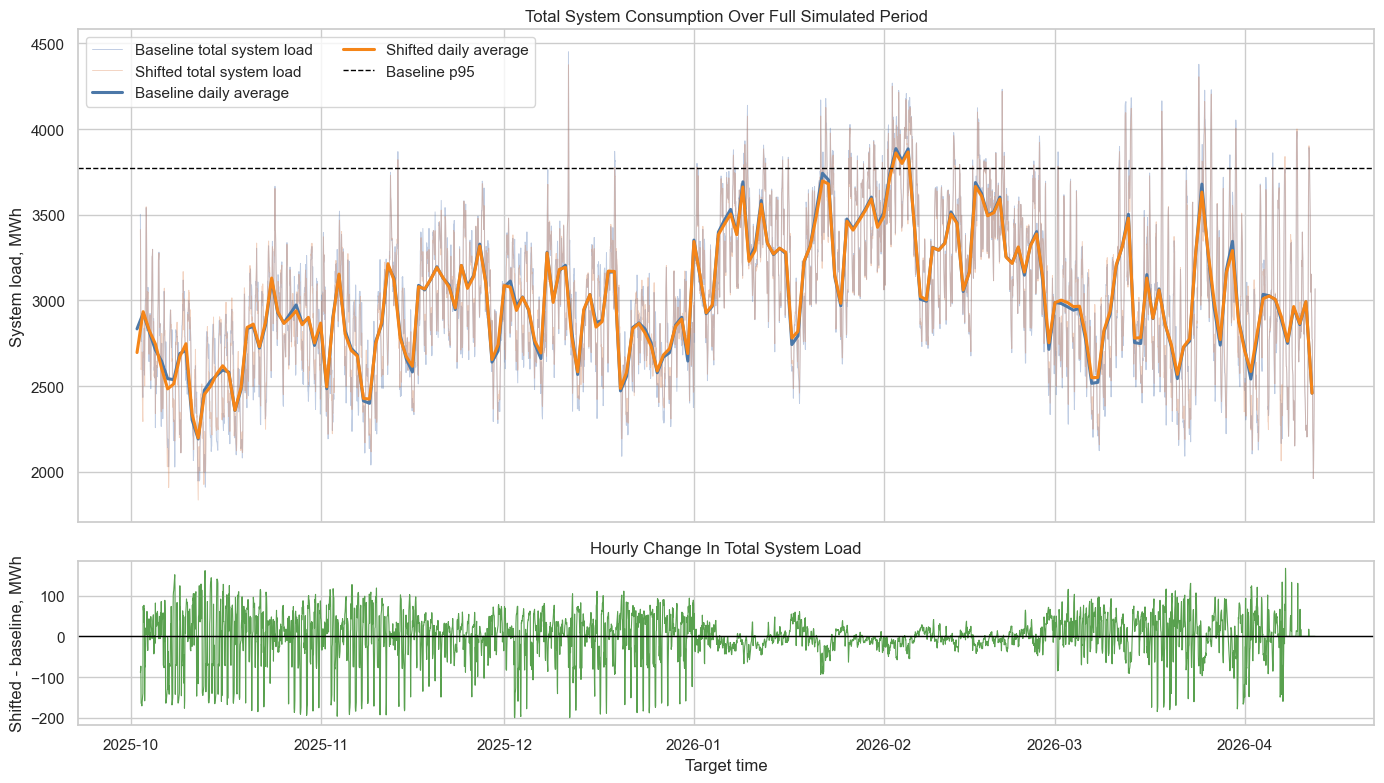

,value
baseline_total_system_consumption_mwh,1.385969e+07
shifted_total_system_consumption_mwh,1.385969e+07
system_consumption_delta_mwh,0.000000e+00
mean_hourly_system_load_delta_mwh,-5.738761e-15
max_hourly_system_load_reduction_mwh,-2.001324e+02
max_hourly_system_load_increase_mwh,1.674932e+02


In [7]:
full_period_system_load = profiles.sort_values("target_time").set_index("target_time")
daily_system_load = full_period_system_load[
    ["system_load_mwh", "shifted_system_load_mwh", "system_load_delta_mwh"]
].resample("D").mean()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

axes[0].plot(
    full_period_system_load.index,
    full_period_system_load["system_load_mwh"],
    label="Baseline total system load",
    linewidth=0.7,
    alpha=0.35,
)
axes[0].plot(
    full_period_system_load.index,
    full_period_system_load["shifted_system_load_mwh"],
    label="Shifted total system load",
    linewidth=0.7,
    alpha=0.35,
)
axes[0].plot(
    daily_system_load.index,
    daily_system_load["system_load_mwh"],
    label="Baseline daily average",
    linewidth=2.2,
    color="#4C78A8",
)
axes[0].plot(
    daily_system_load.index,
    daily_system_load["shifted_system_load_mwh"],
    label="Shifted daily average",
    linewidth=2.2,
    color="#F58518",
)
axes[0].axhline(
    baseline_p95,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Baseline p95",
)
axes[0].set_ylabel("System load, MWh")
axes[0].set_title("Total System Consumption Over Full Simulated Period")
axes[0].legend(ncol=2)

axes[1].plot(
    full_period_system_load.index,
    full_period_system_load["system_load_delta_mwh"],
    color="#59A14F",
    linewidth=0.8,
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("Shifted - baseline, MWh")
axes[1].set_xlabel("Target time")
axes[1].set_title("Hourly Change In Total System Load")

plt.tight_layout()
plt.show()

full_period_system_totals = pd.Series({
    "baseline_total_system_consumption_mwh": full_period_system_load["system_load_mwh"].sum(),
    "shifted_total_system_consumption_mwh": full_period_system_load["shifted_system_load_mwh"].sum(),
    "system_consumption_delta_mwh": (
        full_period_system_load["shifted_system_load_mwh"].sum()
        - full_period_system_load["system_load_mwh"].sum()
    ),
    "mean_hourly_system_load_delta_mwh": full_period_system_load["system_load_delta_mwh"].mean(),
    "max_hourly_system_load_reduction_mwh": full_period_system_load["system_load_delta_mwh"].min(),
    "max_hourly_system_load_increase_mwh": full_period_system_load["system_load_delta_mwh"].max(),
})

full_period_system_totals.to_frame("value")


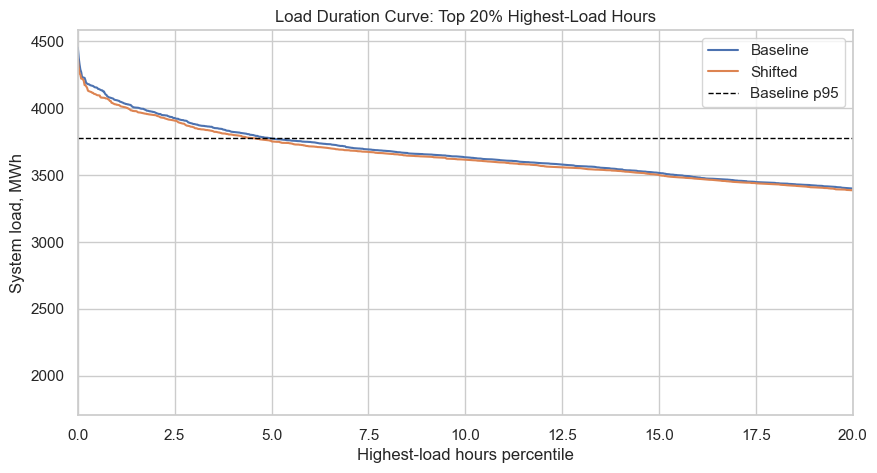

In [8]:
load_duration = pd.DataFrame({
    "Baseline": profiles["system_load_mwh"].sort_values(ascending=False).to_numpy(),
    "Shifted": profiles["shifted_system_load_mwh"].sort_values(ascending=False).to_numpy(),
})
load_duration["rank_pct"] = np.arange(len(load_duration)) / len(load_duration) * 100

plt.figure(figsize=(10, 5))
plt.plot(load_duration["rank_pct"], load_duration["Baseline"], label="Baseline")
plt.plot(load_duration["rank_pct"], load_duration["Shifted"], label="Shifted")
plt.axhline(baseline_p95, color="black", linestyle="--", linewidth=1, label="Baseline p95")
plt.xlim(0, 20)
plt.xlabel("Highest-load hours percentile")
plt.ylabel("System load, MWh")
plt.title("Load Duration Curve: Top 20% Highest-Load Hours")
plt.legend()
plt.show()


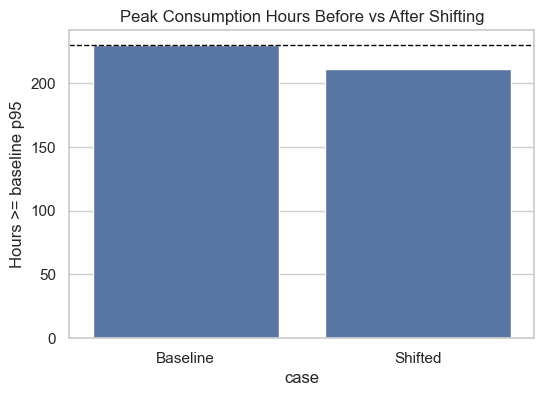

In [9]:
peak_counts = pd.DataFrame({
    "case": ["Baseline", "Shifted"],
    "peak_hours": [
        profiles["baseline_peak_hour"].sum(),
        profiles["shifted_peak_hour"].sum(),
    ],
})

plt.figure(figsize=(6, 4))
sns.barplot(data=peak_counts, x="case", y="peak_hours")
plt.axhline(profiles["baseline_peak_hour"].sum(), color="black", linestyle="--", linewidth=1)
plt.ylabel("Hours >= baseline p95")
plt.title("Peak Consumption Hours Before vs After Shifting")
plt.show()


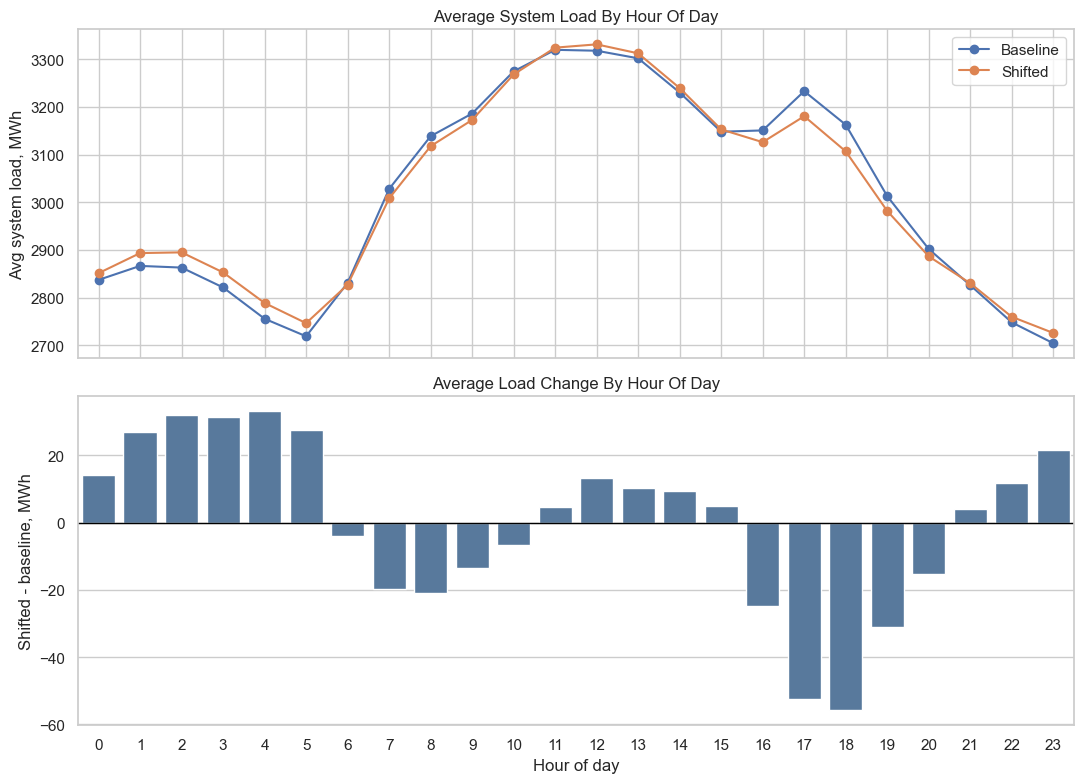

In [10]:
hourly_load = profiles.groupby("hour", as_index=False).agg(
    baseline_load_mwh=("system_load_mwh", "mean"),
    shifted_load_mwh=("shifted_system_load_mwh", "mean"),
    delta_mwh=("system_load_delta_mwh", "mean"),
)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(hourly_load["hour"], hourly_load["baseline_load_mwh"], marker="o", label="Baseline")
axes[0].plot(hourly_load["hour"], hourly_load["shifted_load_mwh"], marker="o", label="Shifted")
axes[0].set_ylabel("Avg system load, MWh")
axes[0].set_title("Average System Load By Hour Of Day")
axes[0].legend()

sns.barplot(data=hourly_load, x="hour", y="delta_mwh", ax=axes[1], color="#4C78A8")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("Shifted - baseline, MWh")
axes[1].set_xlabel("Hour of day")
axes[1].set_title("Average Load Change By Hour Of Day")

plt.tight_layout()
plt.show()


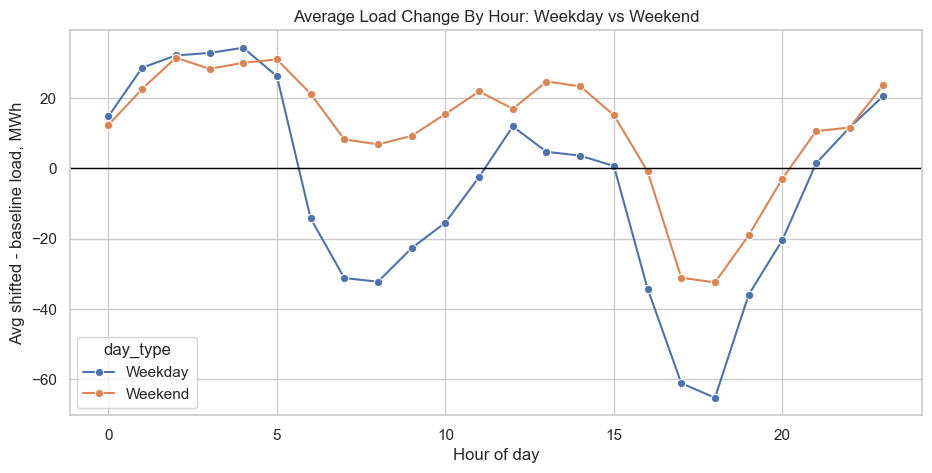

In [11]:
hour_daytype = profiles.groupby(["day_type", "hour"], as_index=False).agg(
    baseline_load_mwh=("system_load_mwh", "mean"),
    shifted_load_mwh=("shifted_system_load_mwh", "mean"),
    delta_mwh=("system_load_delta_mwh", "mean"),
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=hour_daytype, x="hour", y="delta_mwh", hue="day_type", marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Avg shifted - baseline load, MWh")
plt.xlabel("Hour of day")
plt.title("Average Load Change By Hour: Weekday vs Weekend")
plt.show()


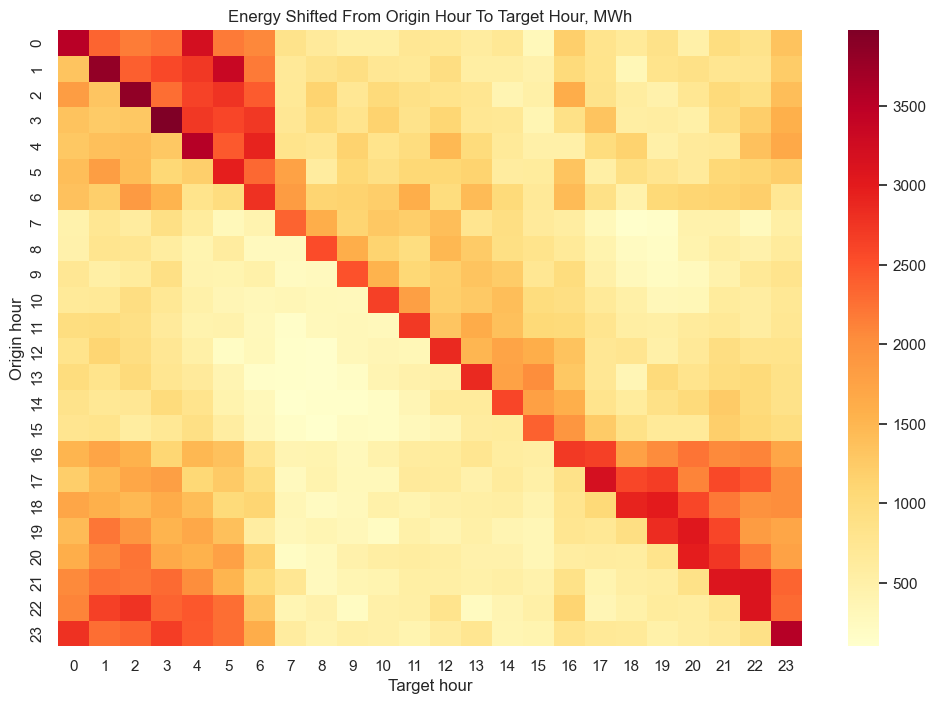

In [12]:
if not shifts.empty:
    shifts["origin_hour"] = shifts["origin_time"].dt.hour
    shifts["target_hour"] = shifts["target_time"].dt.hour
    shifts["origin_day_type"] = np.where(shifts["origin_time"].dt.dayofweek >= 5, "Weekend", "Weekday")
    shifts["target_day_type"] = np.where(shifts["target_time"].dt.dayofweek >= 5, "Weekend", "Weekday")

    heat = shifts.pivot_table(
        index="origin_hour",
        columns="target_hour",
        values="shift_mwh",
        aggfunc="sum",
        fill_value=0,
    )

    plt.figure(figsize=(12, 8))
    sns.heatmap(heat, cmap="YlOrRd")
    plt.xlabel("Target hour")
    plt.ylabel("Origin hour")
    plt.title("Energy Shifted From Origin Hour To Target Hour, MWh")
    plt.show()
else:
    print("No shifts recorded.")


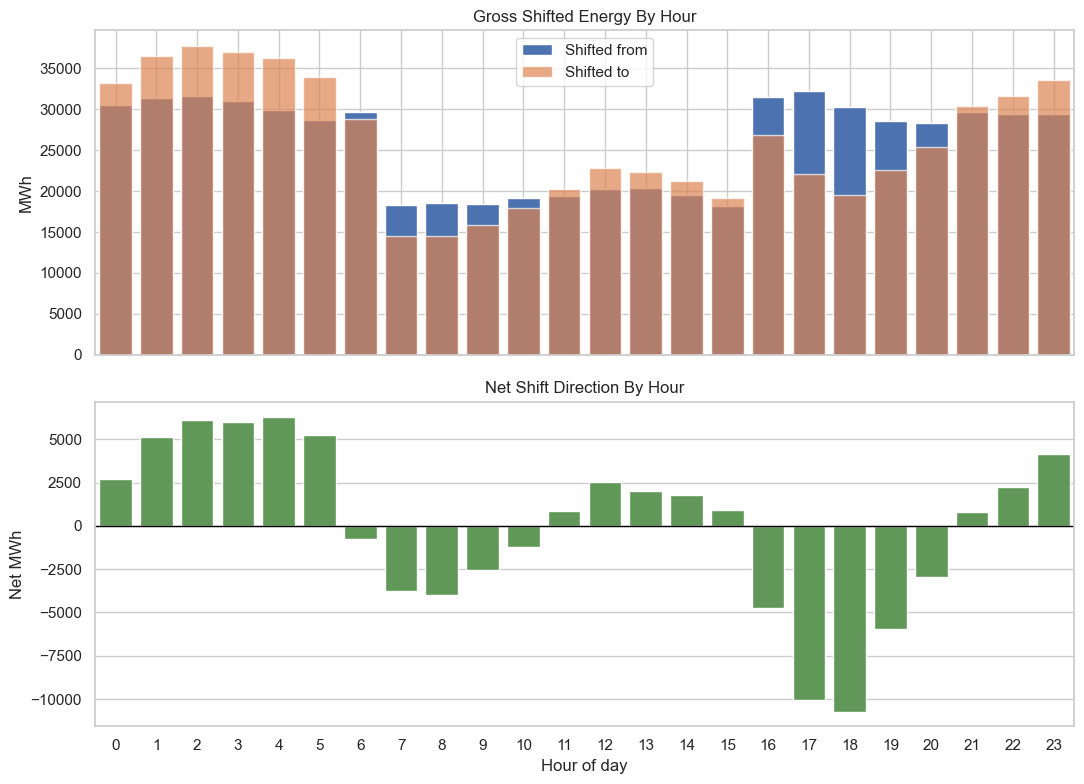

In [13]:
if not shifts.empty:
    from_hour = shifts.groupby("origin_hour")["shift_mwh"].sum()
    to_hour = shifts.groupby("target_hour")["shift_mwh"].sum()

    shift_hour = pd.DataFrame({
        "hour": range(24),
        "shifted_from_mwh": [from_hour.get(h, 0) for h in range(24)],
        "shifted_to_mwh": [to_hour.get(h, 0) for h in range(24)],
    })
    shift_hour["net_to_minus_from_mwh"] = (
        shift_hour["shifted_to_mwh"] - shift_hour["shifted_from_mwh"]
    )

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

    axes[0].bar(shift_hour["hour"], shift_hour["shifted_from_mwh"], label="Shifted from")
    axes[0].bar(shift_hour["hour"], shift_hour["shifted_to_mwh"], alpha=0.7, label="Shifted to")
    axes[0].set_ylabel("MWh")
    axes[0].set_title("Gross Shifted Energy By Hour")
    axes[0].legend()

    sns.barplot(data=shift_hour, x="hour", y="net_to_minus_from_mwh", ax=axes[1], color="#59A14F")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_ylabel("Net MWh")
    axes[1].set_xlabel("Hour of day")
    axes[1].set_title("Net Shift Direction By Hour")

    plt.tight_layout()
    plt.show()


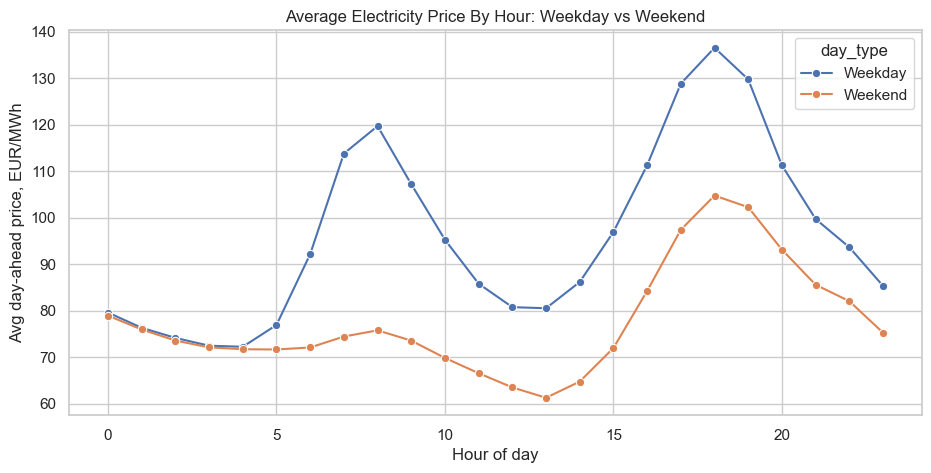

In [14]:
price_hour = profiles.groupby(["day_type", "hour"], as_index=False).agg(
    avg_price_eur_mwh=("DayAheadPriceEUR", "mean"),
    median_price_eur_mwh=("DayAheadPriceEUR", "median"),
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=price_hour, x="hour", y="avg_price_eur_mwh", hue="day_type", marker="o")
plt.ylabel("Avg day-ahead price, EUR/MWh")
plt.xlabel("Hour of day")
plt.title("Average Electricity Price By Hour: Weekday vs Weekend")
plt.show()


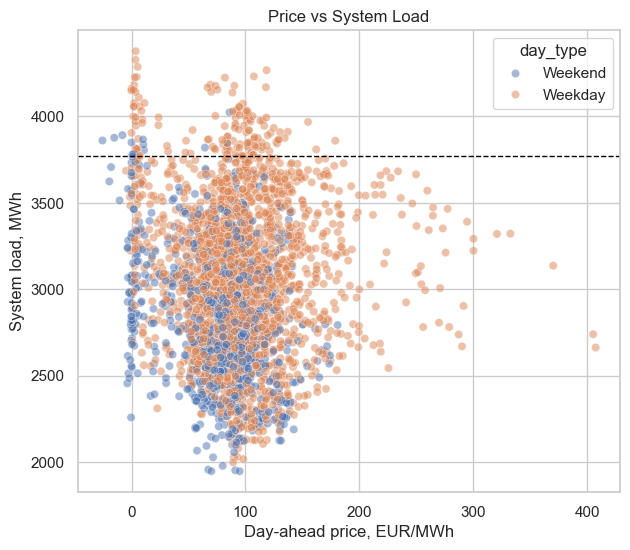

,DayAheadPriceEUR,system_load_mwh
DayAheadPriceEUR,1.000000,-0.049492
system_load_mwh,-0.049492,1.000000


In [15]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=profiles.sample(min(len(profiles), 3000), random_state=42),
    x="DayAheadPriceEUR",
    y="system_load_mwh",
    hue="day_type",
    alpha=0.5,
)
plt.axhline(baseline_p95, color="black", linestyle="--", linewidth=1)
plt.xlabel("Day-ahead price, EUR/MWh")
plt.ylabel("System load, MWh")
plt.title("Price vs System Load")
plt.show()

profiles[["DayAheadPriceEUR", "system_load_mwh"]].corr()


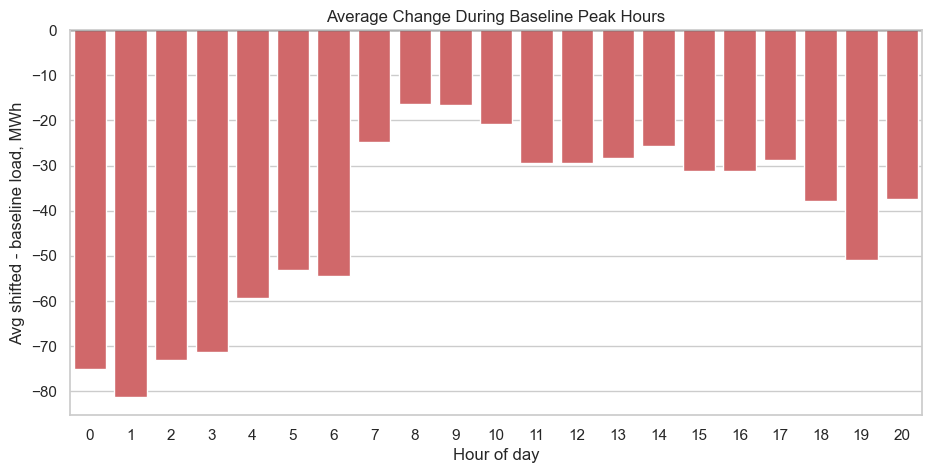

In [16]:
peak_only = profiles[profiles["baseline_peak_hour"]].copy()

peak_effect = peak_only.groupby("hour", as_index=False).agg(
    avg_baseline_peak_load_mwh=("system_load_mwh", "mean"),
    avg_shifted_peak_load_mwh=("shifted_system_load_mwh", "mean"),
    avg_delta_mwh=("system_load_delta_mwh", "mean"),
    n_peak_hours=("target_time", "count"),
)

plt.figure(figsize=(11, 5))
sns.barplot(data=peak_effect, x="hour", y="avg_delta_mwh", color="#E15759")
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Avg shifted - baseline load, MWh")
plt.xlabel("Hour of day")
plt.title("Average Change During Baseline Peak Hours")
plt.show()


<Figure size 1100x600 with 0 Axes>

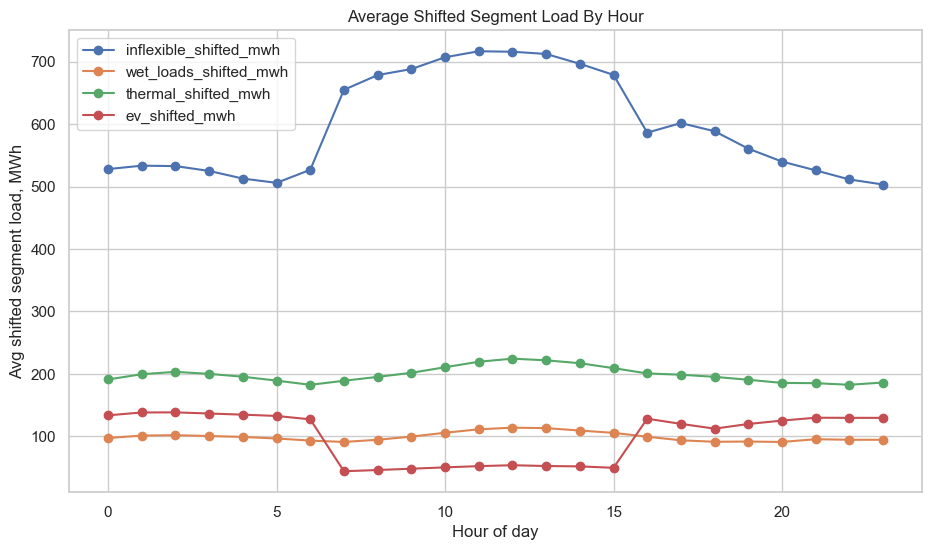

In [17]:
segment_cols = [
    col for col in profiles.columns
    if col.endswith("_shifted_mwh") and col not in ["shifted_household_load_mwh"]
]

segment_hour = profiles.groupby("hour")[segment_cols].mean()

plt.figure(figsize=(11, 6))
segment_hour.plot(kind="line", marker="o", figsize=(11, 6))
plt.ylabel("Avg shifted segment load, MWh")
plt.xlabel("Hour of day")
plt.title("Average Shifted Segment Load By Hour")
plt.show()
